# Set up
**Import libraries**

In [28]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from knmy import knmy
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
)

**Load and merge datasets**

In [2]:

df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

---

## 1. Business Understanding

**Business Objective** 

* The objective of this project is to develop a predictive model for observations of Oryctolagus cuniculus using environmental and temporal factors such as habitat type, seasonality, temperature, precipitation, and geographic location.
The model aims to predict where and when rabbit observations are most likely to occur, helping improve biodiversity monitoring, ecological research, and wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Achieves at least 75% prediction accuracy on unseen observation data
    * Correctly identifies seasonal and habitat-related patterns in rabbit observations
    * Maintains stable performance across different geographic regions and weather conditions

**Data Mining Goals**

* Develop a classification model that predicts the likelihood of observing Oryctolagus cuniculus using environmental variables such as habitat type, seasonality, temperature, precipitation, and geographic location.

**Data Mining Success Criteria**

* Our model should achieve at least:
75% accuracy in predicting observations of Oryctolagus cuniculus
70% precision when identifying locations and time periods with rabbit observations
75% recall in detecting actual rabbit observation occurrences based on habitat, seasonal, and weather-related variables
The model should also maintain stable predictive performance across different regions and seasons.

---

## 2. Data understanding / preparation
**Data exploration**


In [3]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Oryctolagus cuniculus      str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


In [5]:
df.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,5.222995e+01,5.532896e+00,8.136004e+00,2.212651e-01,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,1.501486e+00,1.881532e-01,1.245543e+00,2.249716e-01
std,6.647267e-01,8.779710e-01,6.264853e+01,2.511784e+00,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,1.167872e+00,7.709894e-01,2.688194e+00,7.063523e-01
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,0.000000e+00,9.900000e-02,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,0.000000e+00,3.102000e-01,1.820000e-02
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,2.340000e-02,1.033000e+00,1.417000e-01
max,5.350000e+01,5.340000e+01,1.000400e+05,1.637000e+03,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,1.034430e+01,1.890870e+01,1.422410e+01


**Check data distribution**

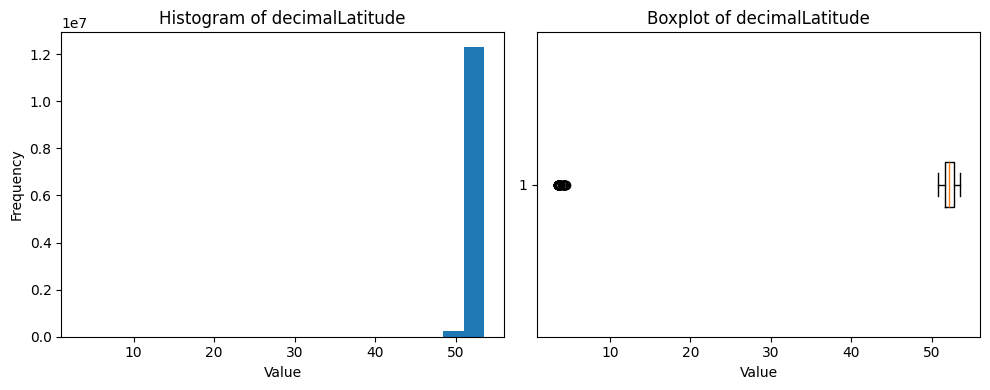

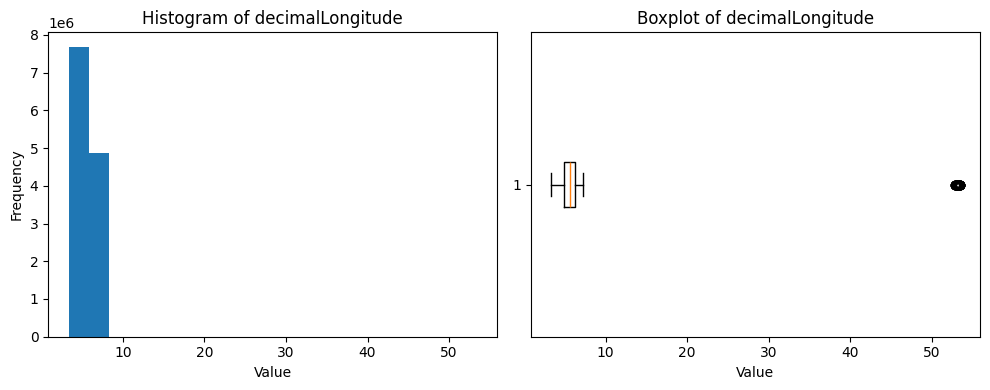

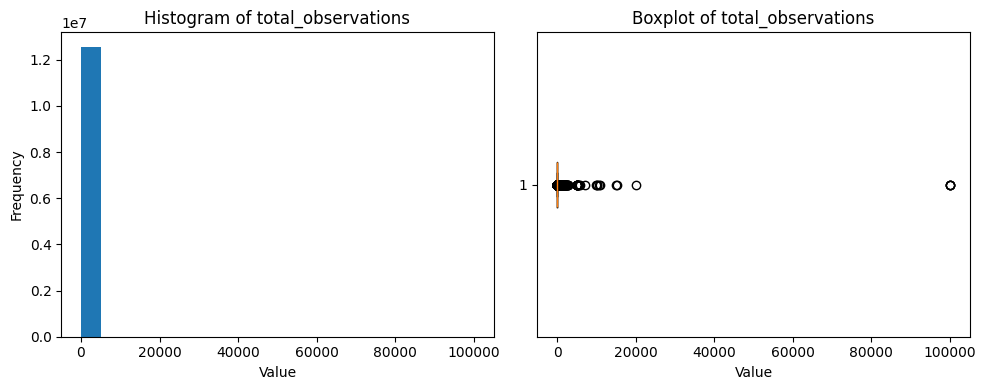

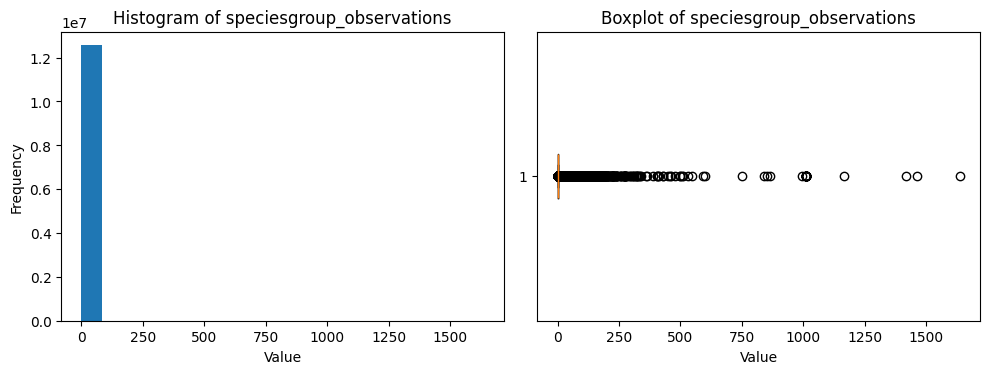

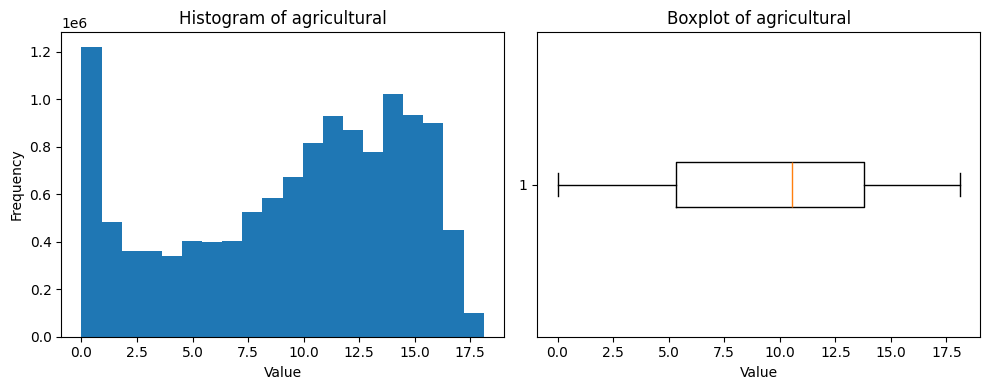

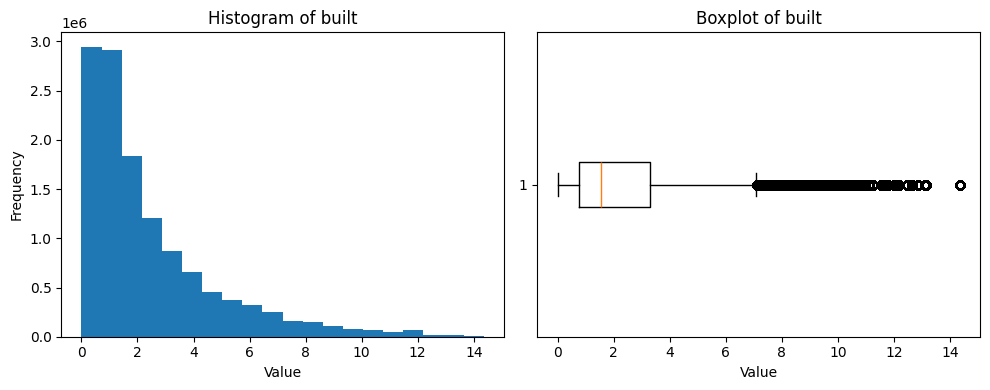

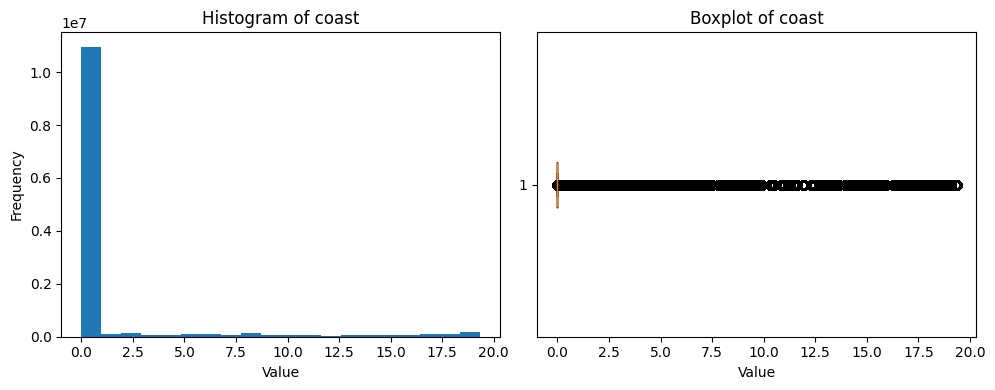

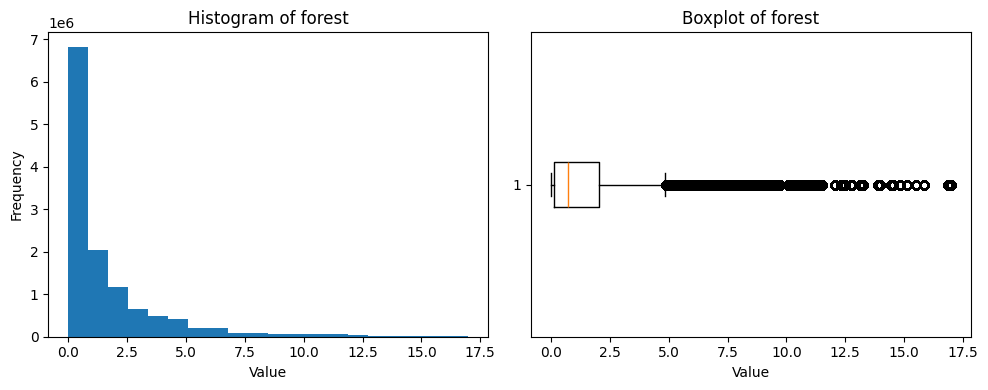

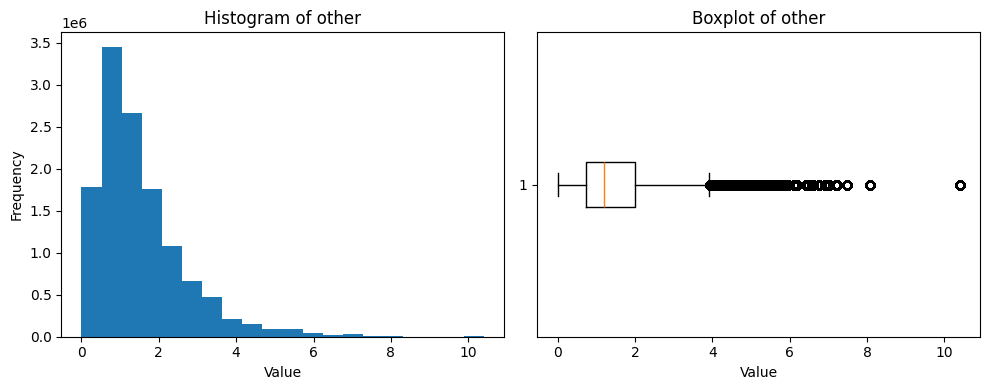

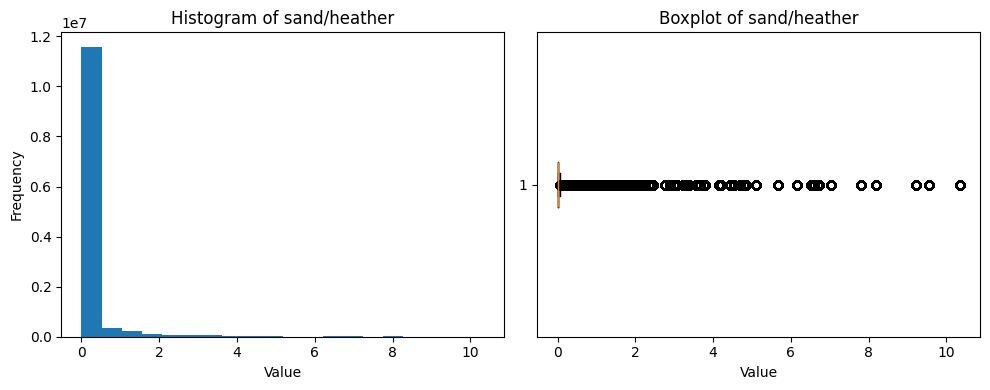

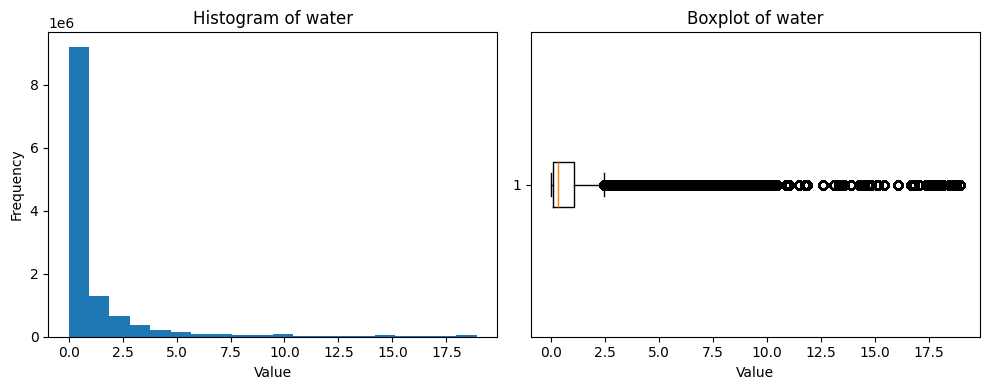

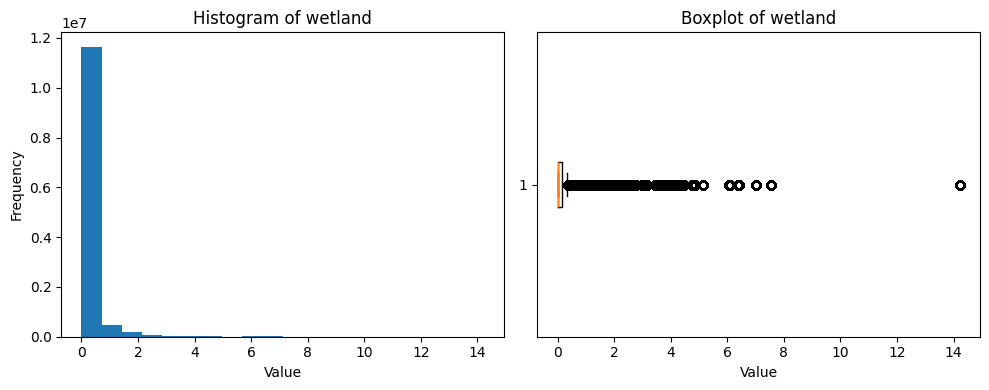

In [6]:
for col in df.describe().columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    axes[0].hist(df[col].dropna(), bins=20)
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Frequency")

    # Boxplot
    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel("Value")

    plt.tight_layout()
    plt.show()

*The histograms and boxplots for total_observations and speciesgroup_observations show that the most common value is zero. Due to the large number of zero values, the distributions are heavily right-skewed, causing even small positive values (greater than 1) to be identified as outliers in the boxplots. Therefore, the detected outliers do not necessarily represent errors or abnormal observations, but rather reflect the strong imbalance between zero and non-zero counts in the data.*

**Feature engineering**

*We saw that our target variable was a string. To make it easier to work with we converted all string to numbers*

In [7]:
df["Oryctolagus cuniculus"] = pd.to_numeric(
    df["Oryctolagus cuniculus"],
    errors="coerce"
).astype("Int64")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Oryctolagus cuniculus      Int64  
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: Int64(1), float64(11), int64(1), str(2)
memory usage: 1.4 GB


*We extracted year and week from eventDate to group daily observations into weekly periods. We then grouped the data by year and week and created IsSpottedInWeek, which is True if Oryctolagus cuniculus was greater than 0 at least once in that week. This converts daily sightings into a weekly binary target, focusing on whether rabbits were observed in a given week rather than how many were seen each day.*

In [41]:
df["eventDate"] = pd.to_datetime(df["eventDate"])
df["year"] = df["eventDate"].dt.isocalendar().year
df["week"] = df["eventDate"].dt.isocalendar().week

weekly = df.groupby(["year", "week"])["Oryctolagus cuniculus"].max() > 0

df["IsSpottedInWeek"] = df.set_index(["year", "week"]).index.map(weekly)
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,precip_sum,sunshine_duration,is_weekend,day_of_year,day_sin,day_cos,month,year,week,IsSpottedInWeek
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-0.1,4.2,0,1,0.017213,0.999852,1,2009,53,True
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,...,0.1,0.0,1,2,0.034422,0.999407,1,2009,53,True
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,...,0.0,6.2,1,3,0.051620,0.998667,1,2009,53,True
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-0.1,1.0,0,4,0.068802,0.997630,1,2010,1,True
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,0.9,3.3,0,5,0.085965,0.996298,1,2010,1,True


**Check duplicates, missing values or typos**

In [9]:
df.isnull().sum()

decimalLatitude               0
decimalLongitude              0
eventDate                     0
total_observations            3
speciesgroup_observations     0
Oryctolagus cuniculus         5
agricultural                 30
built                        30
coast                        30
forest                       30
other                        30
sand/heather                 30
water                        30
wetland                      30
main_habitat                 30
is_spotted                    5
dtype: int64

In [10]:
df = df.dropna()
#check for missing values
df.isnull().sum()   

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Oryctolagus cuniculus        0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
is_spotted                   0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


In [13]:
df["eventDate"] = pd.to_datetime(df["eventDate"]).dt.normalize()

start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_raw = knmy.get_knmi_data(
    type="daily",
    stations=[260],
    start=start_date,
    end=end_date
)

# KNMI data starts with a header after the '#' comments. 
# We skip the comments and treat it as a standard CSV.
# We use skipinitialspace=True to handle the alignment spaces.
weather_df = pd.read_csv(
    StringIO(weather_raw), 
    comment='#', 
    skipinitialspace=True,
    header=None
)

# Mapping based on standard KNMI daily index:
# 0: STN, 1: YYYYMMDD, 11: TG, 18: SQ, 22: RH
weather_df = weather_df.rename(columns={
    0: "STN",
    1: "YYYYMMDD",
    11: "TG",
    18: "SQ",
    22: "RH"
})

# Ensure YYYYMMDD is treated as a string before date conversion
weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)

weather_df["eventDate"] = pd.to_datetime(
    weather_df["YYYYMMDD"], 
    format="%Y%m%d", 
    errors="coerce"
).dt.normalize()

# KNMI values are in 0.1 units (e.g., 115 = 11.5°C)
weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10


weather_df = weather_df.dropna(subset=["eventDate"])


df["eventDate"] = df["eventDate"].dt.normalize()
weather_df["eventDate"] = weather_df["eventDate"].dt.normalize()

df = df.merge(
    weather_df[[
        "eventDate",
        "temp_mean",
        "precip_sum",
        "sunshine_duration"
    ]],
    on="eventDate",
    how="left"
)

df["is_weekend"] = df["eventDate"].dt.weekday.isin([5, 6]).astype(int)
df["day_of_year"] = df["eventDate"].dt.dayofyear
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

print("✔ Shape:", df.shape)
print(df.head())

✔ Shape: (12558756, 23)
   decimalLatitude  decimalLongitude  eventDate  total_observations  \
0            50.75              5.65 2010-01-01                 0.0   
1            50.75              5.65 2010-01-02                26.0   
2            50.75              5.65 2010-01-03                 3.0   
3            50.75              5.65 2010-01-04                 0.0   
4            50.75              5.65 2010-01-05                 0.0   

   speciesgroup_observations  Oryctolagus cuniculus  agricultural   built  \
0                          0                      0        1.7747  0.0568   
1                          0                      0        1.7747  0.0568   
2                          0                      0        1.7747  0.0568   
3                          0                      0        1.7747  0.0568   
4                          0                      0        1.7747  0.0568   

   coast  forest  ...  wetland  main_habitat  is_spotted  temp_mean  \
0    0.0  0.061

Merged the KMNI data to our dataset by using like an api. Currently one down side is that it is only from one location.
Further more did feature coding by making is_weekend, day_of_year and then also day_sin and day_cos for the model later so that it understands that day 365 is close to day 1. Made is_weekend so that we can later check observer bias and made day of year to seasonal patterns.


**Check heatmap correlation**

c:\Hz\2e\ddd\Rabbitions\venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Hz\2e\ddd\Rabbitions\venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


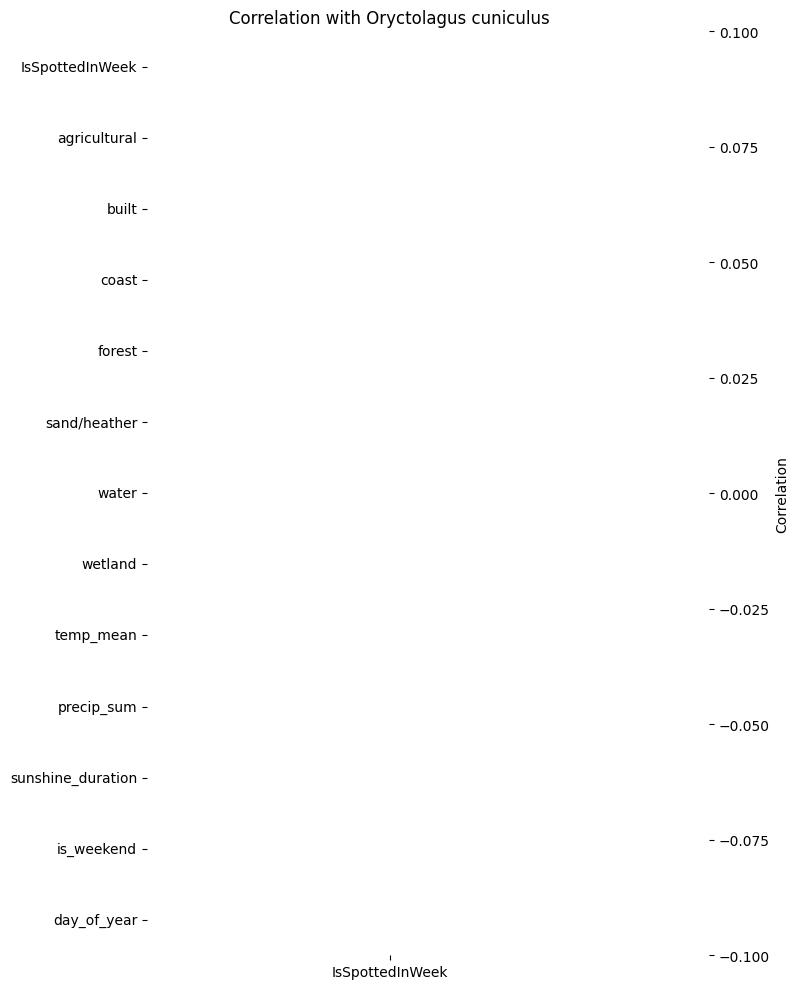

In [ ]:
cols = [
    'is_spotted',
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration',
    'is_weekend', 'day_of_year'
]

df_clean = df[cols].replace("unknown", pd.NA)

# convert boolean target to integer (True=1, False=0)
df_clean['is_spotted'] = df_clean['is_spotted'].astype(int)

# drop rows with missing values
df_clean = df_clean.dropna()

corr = df_clean.corr()

# extract correlation with target
target_corr = corr[['is_spotted']].sort_values(
    by='is_spotted',
    ascending=False
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    target_corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title("Correlation with Oryctolagus cuniculus")
plt.tight_layout()
plt.show()

**Findings**

As you can see in the heatmap above there are no correlations with any variables

**Habitat differences between rabbit presence and absence locations**

In [15]:
habitat_cols = [
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland"
]

# group means per habitat type
group_means = df.groupby("is_spotted")[habitat_cols].mean()

print(group_means)

            agricultural     built     coast    forest     other  \
is_spotted                                                         
False           9.468689  2.398551  1.297686  1.619056  1.497947   
True            6.470470  3.546110  2.256118  2.007850  2.144608   

            sand/heather     water   wetland  
is_spotted                                    
False           0.187826  1.245827  0.225136  
True            0.247568  1.194101  0.195133  


**Findings**

Rabbit presence is associated with slightly higher forest and sand/heather habitats (differences of approximately +0.12 for forest and +0.05 for sand/heather). Other land types such as agriculture, built areas, and coastal regions show minimal differences between presence and absence locations. Overall, the results suggest that no single habitat strongly determines rabbit occurrence on its own. Habitat preferences are likely subtle and influenced by combinations of environmental factors rather than individual variables.

**Diagrams between presence and absence rabbits**

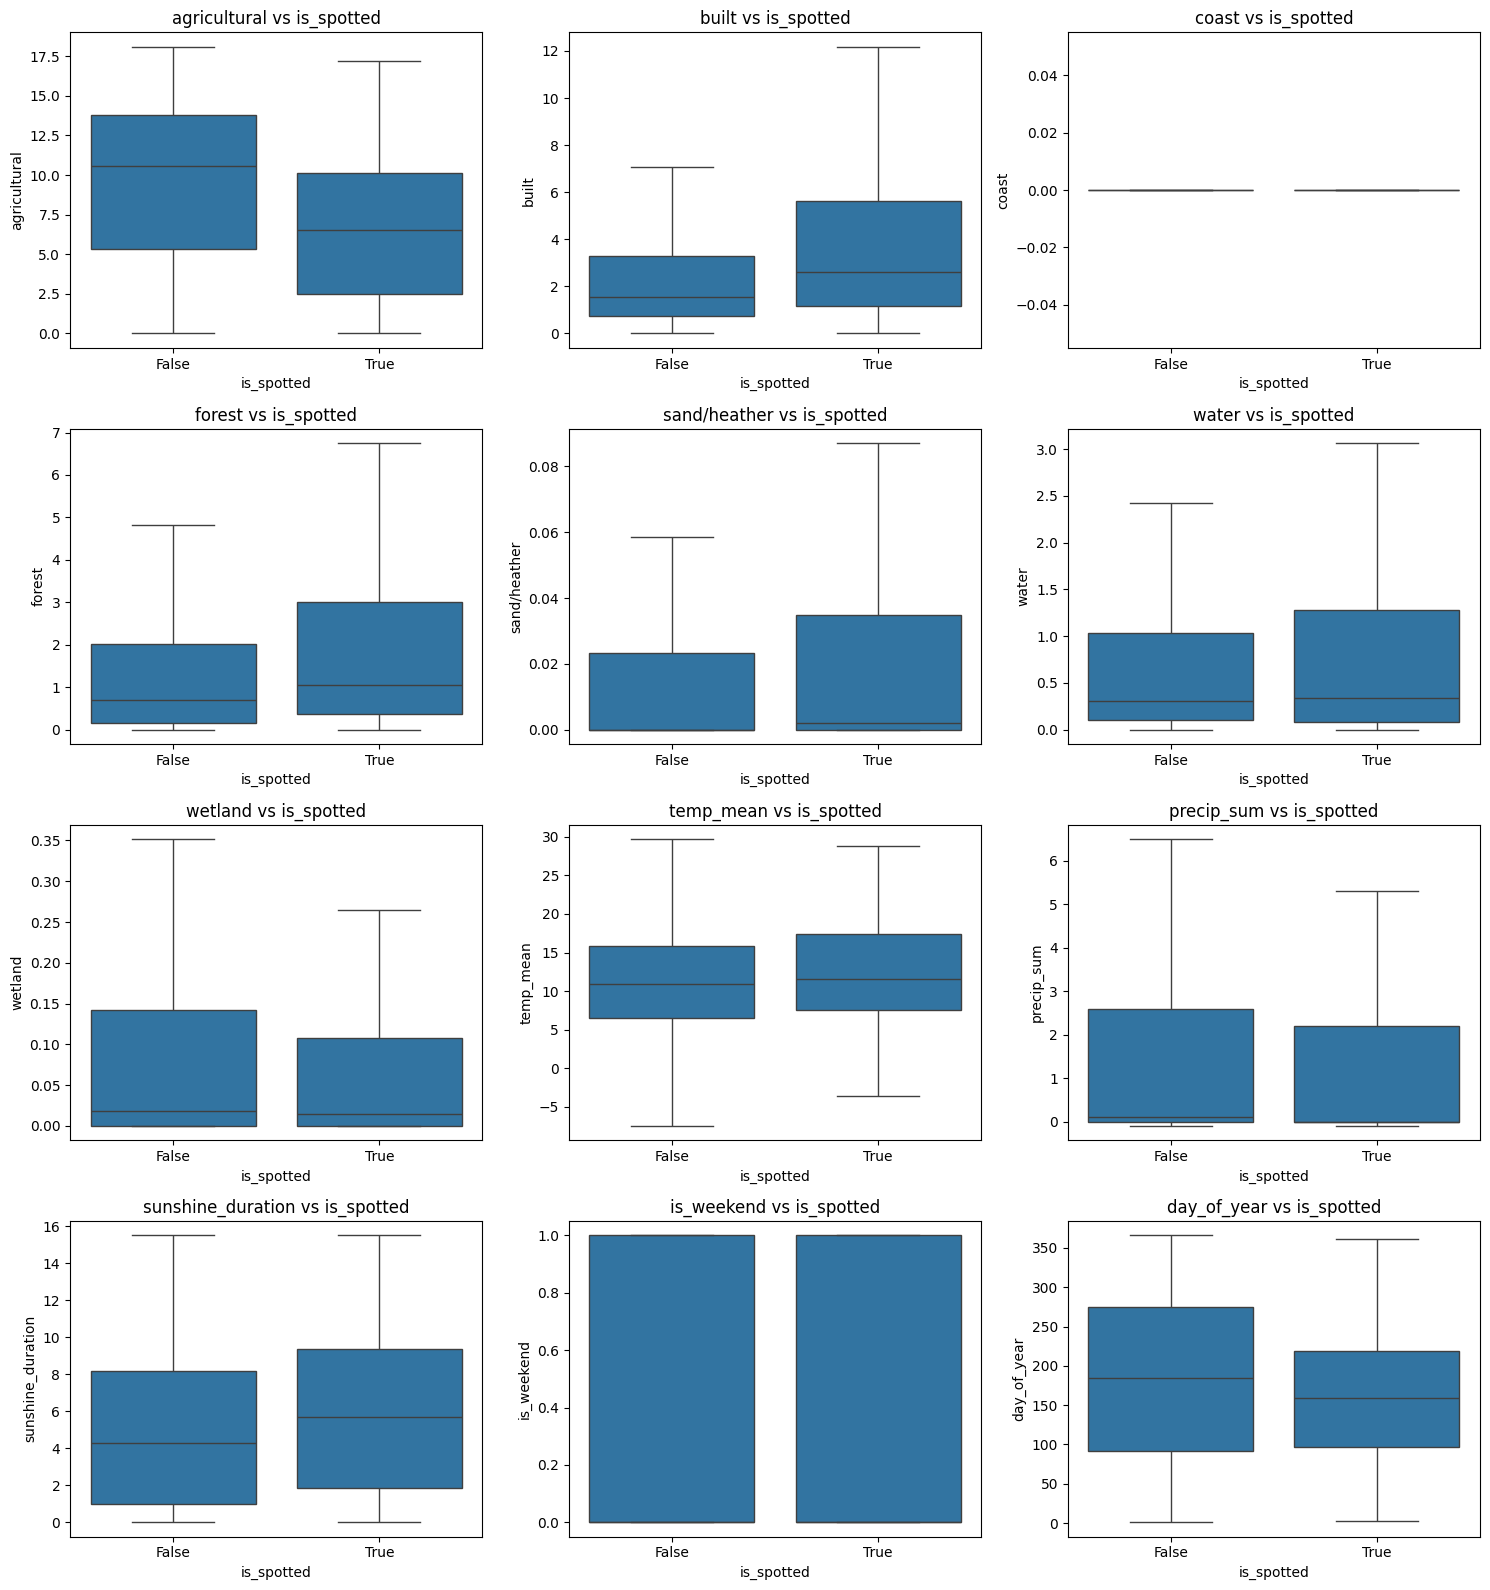

In [16]:
features = [
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration',
    'is_weekend', 'day_of_year'
]

target = 'is_spotted'

df_plot = df[[target] + features].copy()

df_plot = df_plot.replace("unknown", pd.NA)
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

df_plot = df_plot.dropna()

# Sample for speed
df_plot = df_plot.sample(50000, random_state=42)

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        x=target,
        y=col,
        data=df_plot,
        showfliers=False
    )

    plt.title(f"{col} vs is_spotted")

plt.tight_layout()
plt.show()

## Findings

from these graphs we can see that most data are very similair to if spotted or not. 
A few noticeble differences are for example if built is higher than 7 is it is most likely spotted, water higher than 2.4 aswell most likely spotted, wetland higher than 0.35 most likely spotted and if precip_sum is higher than 4.8 it is most likely not spotted.

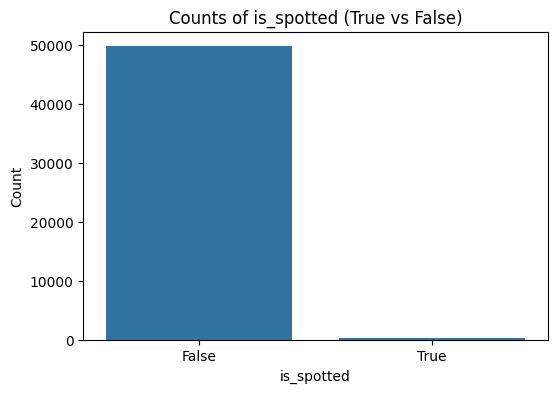

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_spotted', data=df_plot)

plt.title('Counts of is_spotted (True vs False)')
plt.xlabel('is_spotted')
plt.ylabel('Count')

plt.show()

With this graph we can see that around 10% of the data has spotted as true

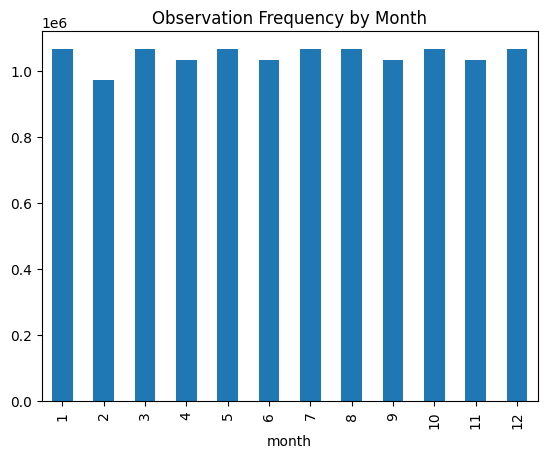

In [18]:
df["eventDate"] = pd.to_datetime(df["eventDate"])

df["month"] = df["eventDate"].dt.month

df["month"].value_counts().sort_index().plot(kind="bar")

plt.title("Observation Frequency by Month")
plt.show()

this was to check how many observations were made monthly and as you can see its all pretty equal to the days in the months

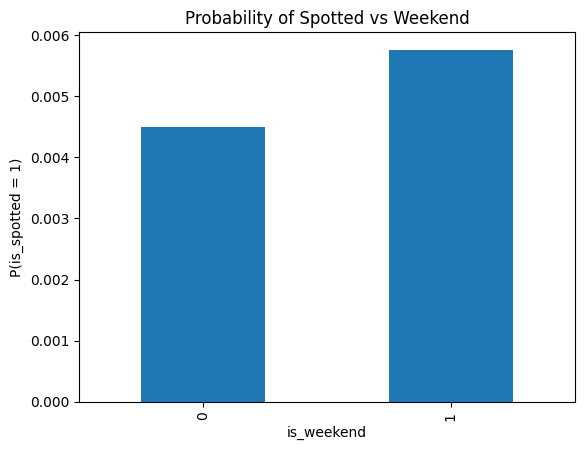

In [19]:
df_plot['is_spotted'] = df_plot['is_spotted'].astype(int)

rate = df_plot.groupby('is_weekend')['is_spotted'].mean()

rate.plot(kind='bar')
plt.title('Probability of Spotted vs Weekend')
plt.ylabel('P(is_spotted = 1)')
plt.xlabel('is_weekend')
plt.show()

## Findings

As you can see weekend is almost as high as non weekend, this means there really could be a observer bias since the weekend only has 2 days and the non weekend has 5 days. If there were no bias the non weekend should have 2,5 times as much instead of the 1,1 times as much as we can see now.

**Filter spotted rabbit habitats**

In [20]:
# filter spotted rabbits
hab = df[df["is_spotted"] == 1]["main_habitat"]

# counts
counts = hab.value_counts(dropna=False)

# percentages
percentages = hab.value_counts(normalize=True, dropna=False) * 100

# combine into one dataframe
result = pd.DataFrame({
    "count": counts,
    "percentage": percentages.round(2)
})

print(result)

              count  percentage
main_habitat                   
agricultural  35528       51.68
built         13143       19.12
coast         12077       17.57
forest         4524        6.58
water          2543        3.70
other           575        0.84
sand/heather    223        0.32
wetland         134        0.19


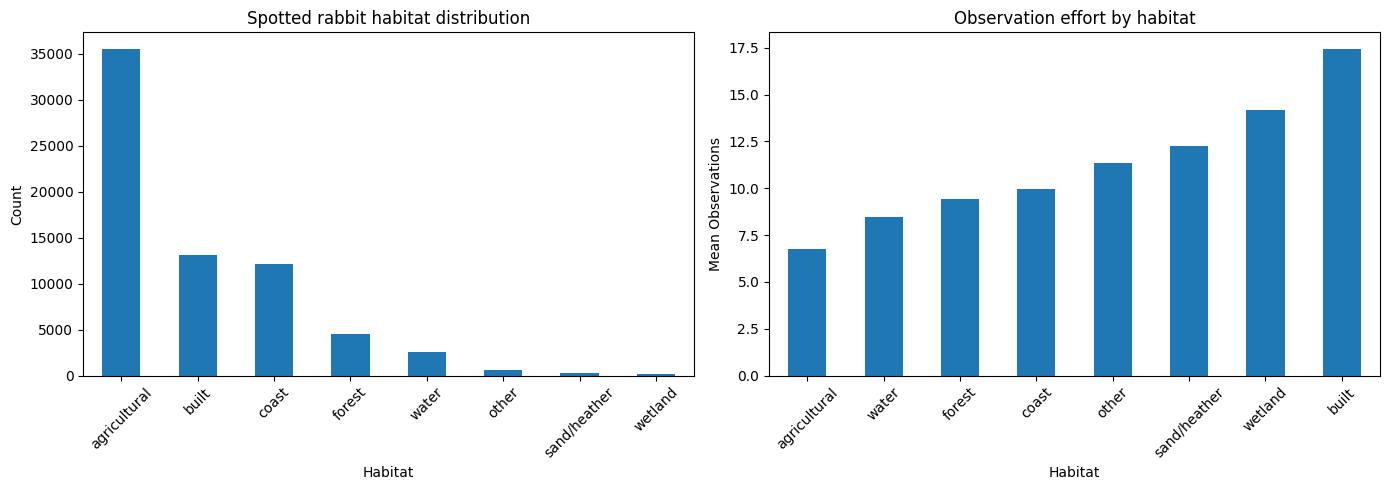

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================================
# 1. Spotted rabbit habitat distribution
# =========================================
df[df["is_spotted"] == 1]["main_habitat"] \
    .value_counts() \
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Spotted rabbit habitat distribution")
axes[0].set_xlabel("Habitat")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# =========================================
# 2. Observation effort by habitat
# =========================================
df.groupby("main_habitat")["total_observations"] \
    .mean() \
    .sort_values() \
    .plot(kind="bar", ax=axes[1])

axes[1].set_title("Observation effort by habitat")
axes[1].set_xlabel("Habitat")
axes[1].set_ylabel("Mean Observations")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Findings**

Most rabbit observations are recorded in agricultural environments (68.75%), followed by built areas (12.41%). However, this distribution does not necessarily reflect true habitat preference, as observation effort varies across habitats.

The observation effort analysis shows that built areas and wetlands have a higher average number of observations. This indicates a potential sampling bias, likely due to these areas being more accessible or more frequently surveyed.

Interestingly, agricultural areas show the highest number of rabbit sightings despite not having the highest observation effort. This may suggest that rabbit presence is genuinely higher in these environments, rather than being solely driven by survey intensity.

Other habitats, such as sand/heather, wetlands, and forest, show relatively low observation effort and low numbers of sightings. Therefore, conclusions about rabbit habitat preference in these environments are less reliable.

**Rabbit spots related to habitat**

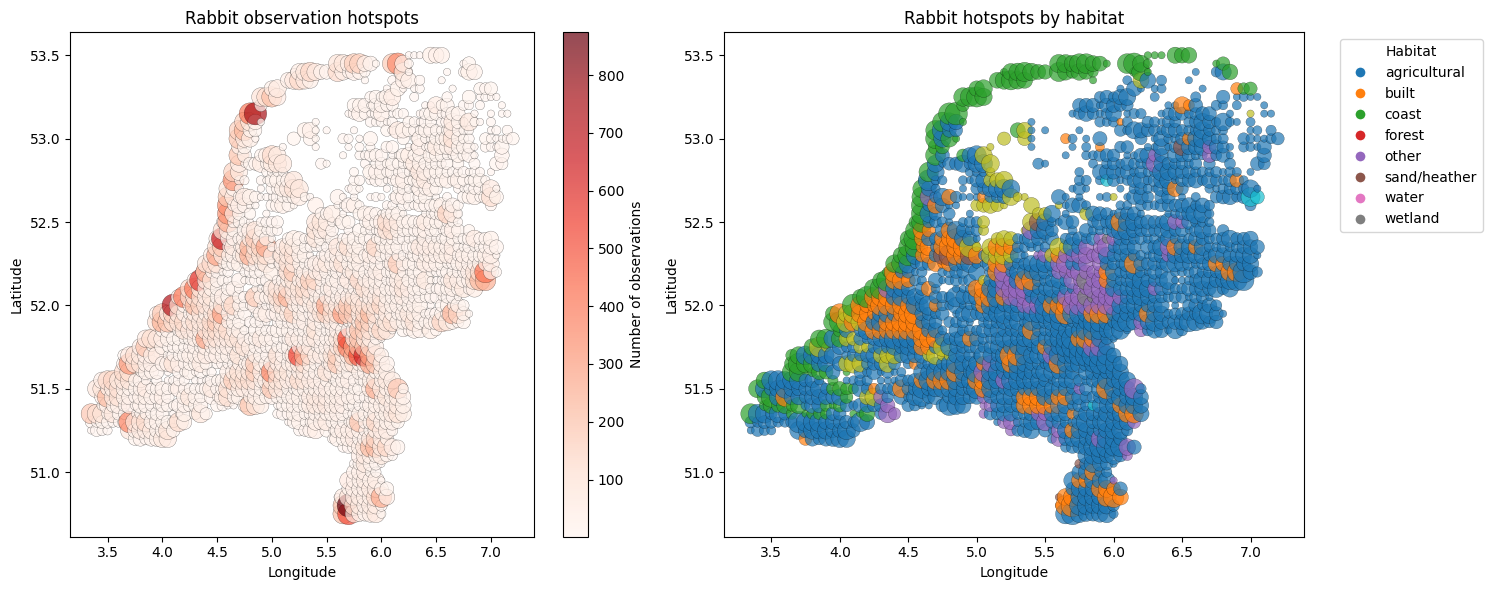

In [22]:
df_spotted = df[df["is_spotted"] == 1]

# =========================================
# 1. Location-only hotspot map
# =========================================
loc_counts_1 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude"]
).size().reset_index(name="count")

loc_counts_1["log_count"] = np.log1p(loc_counts_1["count"])

# =========================================
# 2. Location + habitat map
# =========================================
loc_counts_2 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude", "main_habitat"]
).size().reset_index(name="count")

loc_counts_2["log_count"] = np.log1p(loc_counts_2["count"])

habitats = loc_counts_2["main_habitat"].astype("category")
colors = habitats.cat.codes

# =========================================
# 3. Create side-by-side plots
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------- LEFT: intensity only --------
sc1 = axes[0].scatter(
    loc_counts_1["decimalLongitude"],
    loc_counts_1["decimalLatitude"],
    s=loc_counts_1["log_count"] * 40,
    c=loc_counts_1["count"],
    cmap="Reds",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[0].set_title("Rabbit observation hotspots")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Number of observations")

# -------- RIGHT: habitat + intensity --------
sc2 = axes[1].scatter(
    loc_counts_2["decimalLongitude"],
    loc_counts_2["decimalLatitude"],
    s=loc_counts_2["log_count"] * 40,
    c=colors,
    cmap="tab10",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[1].set_title("Rabbit hotspots by habitat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# habitat legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cm.tab10(i),
               markersize=8,
               label=cat)
    for i, cat in enumerate(habitats.cat.categories)
]

axes[1].legend(handles=handles, title="Habitat",
               bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Findings**

Most of the rabbit observations are concentrated in specific geographic hotspots, showing a clear uneven spatial distribution of the data. This indicates that the dataset is not uniformly sampled across the study area.

The observation effort map shows that data collection is higher in agricultural and built environments, suggesting a potential sampling bias toward more accessible or frequently surveyed areas.

As a result, the observed habitat distribution of rabbits is likely influenced by where observations are made rather than only true habitat preference. Natural habitats such as forests, wetlands, and sand/heather are less represented, so conclusions about these areas are less reliable.

Train test spilt


In [23]:
features = [
    # spatial
    'decimalLatitude',
    'decimalLongitude',

    # habitats
    'main_habitat',
    'agricultural',
    'built',
    'coast',
    'forest',
    'sand/heather',
    'water',
    'wetland',

    # weather
    'temp_mean',
    'precip_sum',
    'sunshine_duration',

    # temporal
    'is_weekend',
    'day_sin',
    'day_cos',
]

target = 'is_spotted'

In [ ]:
features = [
    # spatial
    'decimalLatitude',
    'decimalLongitude',

    # habitats
    'agricultural',
    'built',
    'coast',
    'forest',
    'sand/heather',
    'water',
    'wetland',

    # weather
    'temp_mean',
    'precip_sum',
    'sunshine_duration',

    # temporal
    'is_weekend',
    'day_sin',
    'day_cos'
]

target = 'is_spotted'

df_model = df[features + [target]].copy()

df_model = df_model.replace("unknown", pd.NA)
df_model = df_model.apply(pd.to_numeric, errors='coerce')

df_model = df_model.dropna()

X = df_model[features]
y = df_model[target]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Original:
is_spotted
False    0.994526
True     0.005474
Name: proportion, dtype: Float64

Train:
is_spotted
False    0.994526
True     0.005474
Name: proportion, dtype: Float64

Test:
is_spotted
False    0.994526
True     0.005474
Name: proportion, dtype: Float64


We train test splitted the data into 80% training and 20% testing sets, while maintaining the same proportion of rabbit observations (is_spotted) in both sets.

Model

In [ ]:
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.575096984097156
              precision    recall  f1-score   support

         0.0       1.00      0.57      0.73   2498003
         1.0       0.01      0.82      0.02     13749

    accuracy                           0.58   2511752
   macro avg       0.50      0.70      0.37   2511752
weighted avg       0.99      0.58      0.72   2511752

Recall: 0.8226780129463961

Confusion Matrix:
[[1433190 1064813]
 [   2438   11311]]


In [ ]:
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y[y==0]) / len(y[y==1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1963075  534928]
 [   2681   11068]]
              precision    recall  f1-score   support

         0.0       1.00      0.79      0.88   2498003
         1.0       0.02      0.81      0.04     13749

    accuracy                           0.79   2511752
   macro avg       0.51      0.80      0.46   2511752
weighted avg       0.99      0.79      0.87   2511752



In [ ]:
# 1. Calculate the class imbalance ratio dynamically
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Instantiate the base model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Define the hyperparameter space to search
# We target the most impactful parameters for XGBoost
param_dist = {
    'n_estimators': [100, 300, 500],          # Number of gradient boosted trees
    'max_depth': [4, 6, 8],                    # Maximum tree depth for base learners
    'learning_rate': [0.01, 0.05, 0.1],        # Boosting learning rate (eta)
    'subsample': [0.7, 0.8, 0.9],              # Subsample ratio of the training instances
    'colsample_bytree': [0.7, 0.8, 0.9],       # Subsample ratio of columns when constructing each tree
    'scale_pos_weight': [ratio]                # Kept static to handle your 10% minority class
}

# 4. Set up RandomizedSearchCV
# Note: We use scoring='f1' or 'roc_auc' because accuracy is misleading for 10% imbalanced data
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,                # Number of parameter settings sampled (Adjust based on your time constraints)
    scoring='f1',             # Focuses on balancing Precision & Recall for the 10% "True" target
    cv=3,                     # 3-fold cross-validation to prevent overfitting
    verbose=2,                # Shows progress during training
    random_state=42,
    n_jobs=-1                 # Uses all available CPU cores for speed
)

# 5. Run the hyperparameter search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 6. Extract the best model and parameters
best_model = random_search.best_estimator_
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}\n")

# 7. Predict and Evaluate using the tuned model
y_pred_tuned = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Tuning Complete ---
Best Parameters Found: {'subsample': 0.8, 'scale_pos_weight': 181.6794428888323, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV F1-Score: 0.0449

Confusion Matrix:
[[2033958  464045]
 [   3159   10590]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.81      0.90   2498003
         1.0       0.02      0.77      0.04     13749

    accuracy                           0.81   2511752
   macro avg       0.51      0.79      0.47   2511752
weighted avg       0.99      0.81      0.89   2511752

